In [1]:
#We make sure to import all the necessary libraries for our analysis
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy.stats import pearsonr, linregress


In [2]:
#We read the datasets into pandas dataframes
df_customer=pd.read_csv('data/olist_customers_dataset.csv')
df_location=pd.read_csv('data/olist_geolocation_dataset.csv')
df_order_items=pd.read_csv('data/olist_order_items_dataset.csv')
df_order_payments=pd.read_csv('data/olist_order_payments_dataset.csv')
df_order_reviews=pd.read_csv('data/olist_order_reviews_dataset.csv')
df_orders=pd.read_csv('data/olist_orders_dataset.csv')
df_products=pd.read_csv('data/olist_products_dataset.csv')
df_sellers=pd.read_csv('data/olist_sellers_dataset.csv')
df_category_translation=pd.read_csv('data/product_category_name_translation.csv')


In [3]:
"""
Questions to answer:
1. VOLUME AND QUANTITY 
Which are the top 10 cities by number of orders?
Which product category is the best-selling?
How many orders per month? Is there a growth trend?
What is the average number of items per order?
"""

'\nQuestions to answer:\n1. VOLUME AND QUANTITY \nWhich are the top 10 cities by number of orders?\nWhich product category is the best-selling?\nHow many orders per month? Is there a growth trend?\nWhat is the average number of items per order?\n'

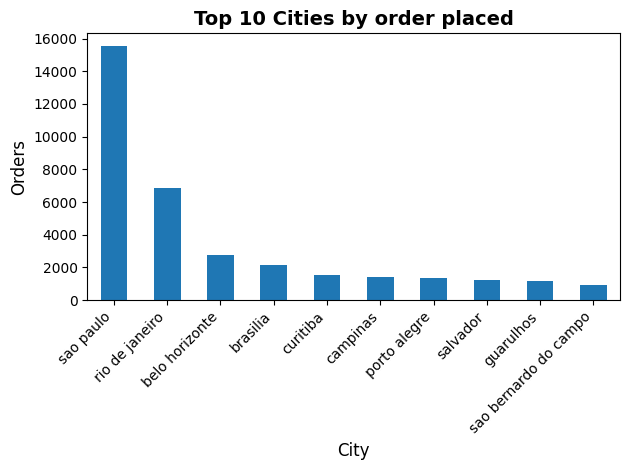

customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: count, dtype: int64


In [45]:
#Which are the top 10 cities by number of orders?
#Joining orders and customers information
df_customers_orders=df_orders.merge(df_customer, how='left', on='customer_id')
top_10_cities=df_customers_orders['customer_city'].value_counts().head(10)
top_10_cities.plot(kind='bar')
plt.title('Top 10 Cities by order placed', fontsize=14, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Orders', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotates city names so they don't overlap
plt.tight_layout()
plt.show()
print(top_10_cities)

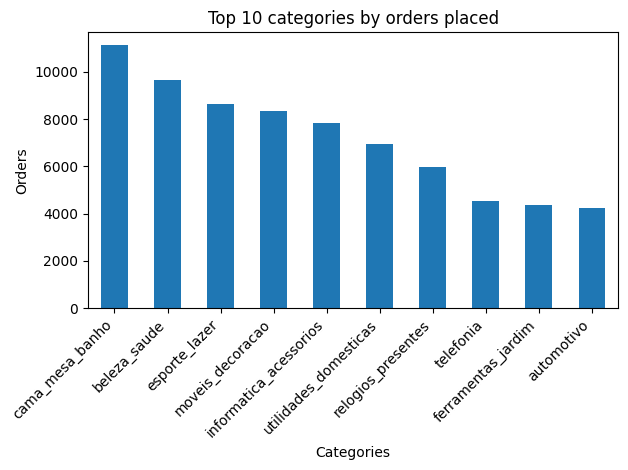

product_category_name
cama_mesa_banho           11115
beleza_saude               9670
esporte_lazer              8641
moveis_decoracao           8334
informatica_acessorios     7827
utilidades_domesticas      6964
relogios_presentes         5991
telefonia                  4545
ferramentas_jardim         4347
automotivo                 4235
Name: count, dtype: int64


In [65]:
#Which product category is the best-selling?
#Joining Orders DataFrame, OrderItems DataFrame, Products Info DataFrame
df_orders_items_info=df_orders.merge(df_order_items,how='left',on='order_id')\
                        .merge(df_products,how='left', on='product_id' )
best_product=df_orders_items_info['product_category_name'].value_counts().head(10)
best_product.plot(kind='bar')
plt.title('Top 10 categories by orders placed')
plt.xlabel('Categories')
plt.ylabel('Orders')
plt.xticks(rotation=45, ha='right')  # Rotates city names so they don't overlap
plt.tight_layout()
plt.show()
print(best_product)

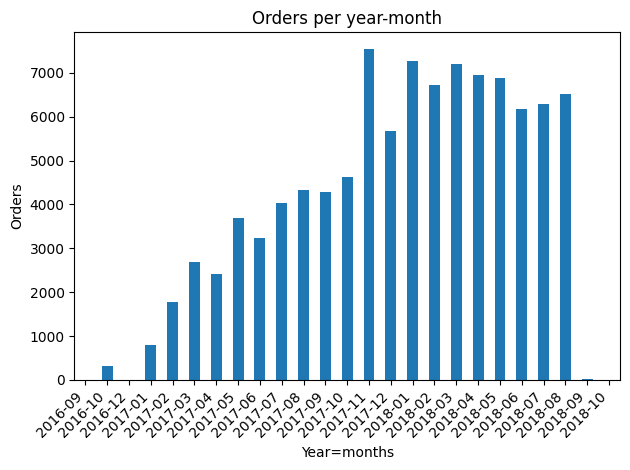

year_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, dtype: int64


In [84]:
#How many orders per month? Is there a growth trend?
#Converting string column into date time data type
df_orders['order_purchase_timestamp']=pd.to_datetime(df_orders['order_purchase_timestamp'])
#Add a column that includes only year-month by using to_period('M')
df_orders['year_month']=df_orders['order_purchase_timestamp'].dt.to_period('M')
#Group by period and calculate de size
orders_per_month = df_orders.groupby('year_month').size()
orders_per_month.plot(kind='bar')
plt.title('Orders per year-month')
plt.xlabel('Year=months')
plt.ylabel('Orders')
plt.xticks(rotation=45, ha='right')  # Rotates city names so they don't overlap
plt.tight_layout()
plt.show()
print(orders_per_month)


In [ ]:
#What is the average number of items per order?
#For this answer re use the same DataFrame created before.
items_per_order=df_order_items.groupby('order_id').size()
avg_items=items_per_order.mean()
print(avg_items)

1.1417306873695092


In [86]:
"""
2. MONEY AND SALES 
What is the average order value?
Which categories generate the most revenue?
What is the correlation between price and quantity sold?
How much does shipping affect the final price?
"""

'\n2. MONEY AND SALES \nWhat is the average order value?\nWhich categories generate the most revenue?\nWhat is the correlation between price and quantity sold?\nHow much does shipping affect the final price?\n'

In [102]:
#What is the average order value?
#Total avg price
avg_price = df_order_items.groupby('order_id', as_index=False).agg(total_order=('price','sum'))['total_order'].mean()
print(avg_price)
#Details of the analisis
order_totals = df_order_items.groupby('order_id')['price'].sum()
print(f'Mean: R${order_totals.mean():.2f}')
print(f'Median: R${order_totals.median():.2f}')
print(f'Range: R${order_totals.min():.2f} - R${order_totals.max():.2f}')



137.7540763788945
Mean: R$137.75
Median: R$86.90
Range: R$0.85 - R$13440.00


     product_category_name  total_revenue  quantity_sold   avg_price  \
11            beleza_saude     1258681.34           9670  130.163531   
66      relogios_presentes     1205005.68           5991  201.135984   
13         cama_mesa_banho     1036988.68          11115   93.296327   
32           esporte_lazer      988048.97           8641  114.344285   
44  informatica_acessorios      911954.32           7827  116.513903   
54        moveis_decoracao      729762.49           8334   87.564494   
26              cool_stuff      635290.85           3796  167.357969   
72   utilidades_domesticas      632248.66           6964   90.788148   
8               automotivo      592720.11           4235  139.957523   
40      ferramentas_jardim      485256.46           4347  111.630196   

    num_products  
11          2444  
66          1329  
13          3029  
32          2867  
44          1639  
54          2657  
26           789  
72          2335  
8           1900  
40           753 

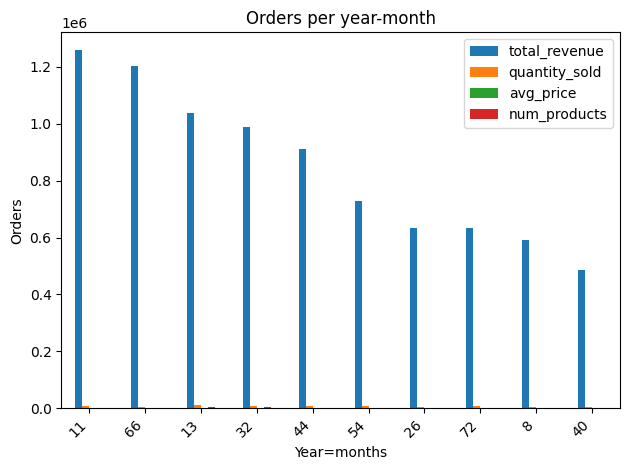

In [ ]:
#Which categories generate the most revenue?
revenue_by_category = df_order_items.merge(df_products, on='product_id') \
    .groupby('product_category_name', as_index=False).agg(
        total_revenue=('price', 'sum'),
        quantity_sold=('order_item_id', 'count'),
        avg_price=('price', 'mean'),
        num_products=('product_id', 'nunique')
    ).sort_values('total_revenue', ascending=False).head(10)
print(revenue_by_category)
revenue_by_category.plot(kind='bar',x='product_category_name',y='total_revenue')
plt.title('Categories with the most revenue')
plt.xlabel('Categories')
plt.ylabel('Revenue')
plt.xticks(rotation=45, ha='right')  # Rotates city names so they don't overlap
plt.tight_layout()
plt.show()



In [ ]:
#What is the correlation between price and quantity sold?
#Calculate how many items were sold by product
quantity_by_product=df_order_items.groupby('product_id',as_index=False).size().reset_index(names='quantity_sold')
print(quantity_by_product)
#Obtain price per product
price_by_product = df_order_items[['product_id', 'price']].drop_duplicates()
print(price_by_product)
product_analysis = quantity_by_product.merge(price_by_product, on='product_id')
correlation = product_analysis['price'].corr(product_analysis['quantity_sold'])
print(correlation)
print(f"Correlación: {correlation:.2f}")

####pending


       quantity_sold                        product_id  size
0                  0  00066f42aeeb9f3007548bb9d3f33c38     1
1                  1  00088930e925c41fd95ebfe695fd2655     1
2                  2  0009406fd7479715e4bef61dd91f2462     1
3                  3  000b8f95fcb9e0096488278317764d19     2
4                  4  000d9be29b5207b54e86aa1b1ac54872     1
...              ...                               ...   ...
32946          32946  fff6177642830a9a94a0f2cba5e476d1     2
32947          32947  fff81cc3158d2725c0655ab9ba0f712c     1
32948          32948  fff9553ac224cec9d15d49f5a263411f     1
32949          32949  fffdb2d0ec8d6a61f0a0a0db3f25b441     5
32950          32950  fffe9eeff12fcbd74a2f2b007dde0c58     1

[32951 rows x 3 columns]
                              product_id   price
0       4244733e06e7ecb4970a6e2683c13e61   58.90
1       e5f2d52b802189ee658865ca93d83a8f  239.90
2       c777355d18b72b67abbeef9df44fd0fd  199.00
3       7634da152a4610f1595efa32f14722fc   12.

In [ ]:
#How much does shipping affect the final price?
#Join orders and orders_items
total_orders=df_order_items['price'].sum()
total_freight_value=df_order_items['freight_value'].sum()
freight_percent=(total_freight_value/total_orders)*100
print(freight_percent)
price_per_order=df_order_items.groupby('order_id')['price'].sum().reset_index()
freight_per_order=df_order_items.groupby('order_id')['freight_value'].sum().reset_index()
total_per_orders=price_per_order.merge(freight_per_order,on='order_id')
print(total_per_orders)
total_per_orders['freight_percent']=(total_per_orders['freight_value']/total_per_orders['price'])*100
print(total_per_orders['freight_percent'].mean())
print(total_per_orders['freight_percent'].median())
print(total_per_orders['freight_percent'].std())


16.56833852994542
                               order_id   price  freight_value
0      00010242fe8c5a6d1ba2dd792cb16214   58.90          13.29
1      00018f77f2f0320c557190d7a144bdd3  239.90          19.93
2      000229ec398224ef6ca0657da4fc703e  199.00          17.87
3      00024acbcdf0a6daa1e931b038114c75   12.99          12.79
4      00042b26cf59d7ce69dfabb4e55b4fd9  199.90          18.14
...                                 ...     ...            ...
98661  fffc94f6ce00a00581880bf54a75a037  299.99          43.41
98662  fffcd46ef2263f404302a634eb57f7eb  350.00          36.53
98663  fffce4705a9662cd70adb13d4a31832d   99.90          16.95
98664  fffe18544ffabc95dfada21779c9644f   55.99           8.72
98665  fffe41c64501cc87c801fd61db3f6244   43.00          12.79

[98666 rows x 3 columns]
30.83886871973845
22.437395659432386
31.47621932533826


In [ ]:

"""3. CUSTOMER SATISFACTION ⭐
What is the average review rating? Is it improving?
Which categories have the best/worst ratings?
Is there a relationship between product price and rating?
Is there a relationship between delivery time and satisfaction?"""

'3. CUSTOMER SATISFACTION ⭐\nWhat is the average review rating? Is it improving?\nWhich categories have the best/worst ratings?\nIs there a relationship between product price and rating?\nIs there a relationship between delivery time and satisfaction?'

In [ ]:
#What is the average review rating? Is it improving?
avg_rating=df_order_reviews['review_score'].mean().round(2)
print(avg_rating)
df_order_reviews['review_answer_timestamp']=pd.to_datetime(df_order_reviews['review_answer_timestamp'])
df_order_reviews['month_year']=df_order_reviews['review_answer_timestamp'].dt.to_period('M')
avg_rating_by_time=df_order_reviews.groupby('month_year')['review_score'].mean().reset_index()
print(avg_rating_by_time)

4.09
   month_year  review_score
0     2016-10      4.158940
1     2016-11      3.218182
2     2016-12      2.360000
3     2017-01      4.398990
4     2017-02      4.290936
5     2017-03      4.028743
6     2017-04      4.049929
7     2017-05      4.085424
8     2017-06      4.121590
9     2017-07      4.177275
10    2017-08      4.224007
11    2017-09      4.195181
12    2017-10      4.183840
13    2017-11      4.110751
14    2017-12      3.947011
15    2018-01      4.042245
16    2018-02      4.013451
17    2018-03      3.768025
18    2018-04      3.883581
19    2018-05      4.196196
20    2018-06      4.175935
21    2018-07      4.287429
22    2018-08      4.209052
23    2018-09      4.308544
24    2018-10      3.944444


In [ ]:
#Which categories have the best/worst ratings?
df_reviews_and_categories=df_order_reviews.merge(df_order_items,on='order_id',how='left')\
                            .merge(df_products,on='product_id',how='left')
df_categories_reviews=df_reviews_and_categories.groupby('product_category_name')['review_score'].mean().reset_index().sort_values(by='review_score',ascending=False)
print(df_categories_reviews.iloc[[0,-1]])



   product_category_name  review_score
17     cds_dvds_musicais      4.642857
67    seguros_e_servicos      2.500000


In [ ]:
#Is there a relationship between product price and rating?
df_reviews_and_categories=df_order_reviews.merge(df_order_items,on='order_id',how='left')\
                            .merge(df_products,on='product_id',how='left')
correlation_price_review=df_reviews_and_categories['price'].corr(df_reviews_and_categories['review_score'])
print(correlation_price_review)


-0.00394087007021197


In [ ]:
#Is there a relationship between delivery time and satisfaction?

df_reviews_and_time=df_order_reviews.merge(df_orders,on='order_id',how='left')\
                            .dropna(subset=['order_delivered_carrier_date', 'review_score'])
df_reviews_and_time['order_purchase_timestamp']=pd.to_datetime(df_reviews_and_time['order_purchase_timestamp'])
df_reviews_and_time['order_delivered_carrier_date']=pd.to_datetime(df_reviews_and_time['order_delivered_carrier_date'])

df_reviews_and_time['delivery_time_days']=(df_reviews_and_time['order_delivered_carrier_date']-df_reviews_and_time['order_purchase_timestamp']).dt.days

correlation, p_value = pearsonr(df_reviews_and_time['delivery_time_days'], df_reviews_and_time['review_score'])

print(f"Correlación: {correlation:.3f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("✓ Relation")
else:
    print("✗ ")

Correlación: -0.156
P-value: 0.0000
✓ Relation


In [ ]:
'''4. TEMPORAL PATTERNS 📅
Which month has the highest sales? Why?
Is there seasonality? (e.g., Christmas, Black Friday)
Are orders increasing or decreasing?
Are ratings improving or worsening over time?'''

'4. TEMPORAL PATTERNS 📅\nWhich month has the highest sales? Why?\nIs there seasonality? (e.g., Christmas, Black Friday)\nAre orders increasing or decreasing?\nAre ratings improving or worsening over time?'

In [ ]:
#Which month has the highest sales? Why?
#Is there seasonality?
#Converting string column into date time data type
#Are orders increasing or decreasing?
df_orders['order_purchase_timestamp']=pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['month']=df_orders['order_purchase_timestamp'].dt.month
#Group by period and calculate de size
orders_per_month = df_orders.groupby('month').size()
print(orders_per_month)
'''Brazilian festivities: 
    Second may sunday, Mothers day
    July, school vacations
    Second agust sunday, Fathers day
'''


month
1      8069
2      8508
3      9893
4      9343
5     10573
6      9412
7     10318
8     10843
9      4305
10     4959
11     7544
12     5674
dtype: int64


'Brazilian festivities: \n    Second may sunday, Mothers day\n    July, school vacations\n    Second agust sunday, Fathers day\n'

In [ ]:
#Are ratings improving or worsening over time?
#We use the same data frame we used before to calculate time and reviews
df_order_reviews['review_creation_date']=pd.to_datetime(df_order_reviews['review_creation_date'])
df_order_reviews['month']=df_order_reviews['review_creation_date'].dt.month
df_review_rate_monthly=df_order_reviews.groupby('month')['review_score'].mean().reset_index()
print(df_review_rate_monthly)

    month  review_score
0       1      4.073855
1       2      4.064413
2       3      3.801147
3       4      3.945622
4       5      4.162339
5       6      4.173609
6       7      4.248003
7       8      4.214826
8       9      4.182424
9      10      4.177276
10     11      4.095764
11     12      3.922761


In [ ]:

'''5. GEOGRAPHY 🗺️
Which are the 5 states with the highest sales?
Is there a difference in price/satisfaction by region?
What is the freight cost by region?'''
df_geography=df_orders.merge(df_customer,on='customer_id',how='left')\
                        .merge(df_order_reviews,on='order_id',how='left')\
                        .merge(df_location,left_on='customer_zip_code_prefix',right_on='geolocation_zip_code_prefix',how='left')

In [ ]:
#Which are the 5 states with the highest sales?
df_sales_by_states=df_geography.groupby('customer_state')['review_score'].size().reset_index().sort_values('review_score',ascending=False)
print(df_sales_by_states.head(5))

   customer_state  review_score
25             SP       5650931
18             RJ       3035729
10             MG       2895463
22             RS        811836
17             PR        628252


In [ ]:
#Is there a difference in price/satisfaction by region?
df_reviews_and_categories_location=df_order_reviews.merge(df_order_items,on='order_id',how='left')\
                            .merge(df_products,on='product_id',how='left')\
                            .merge(df_location,)
correlation_price_review=df_reviews_and_categories['price'].corr(df_reviews_and_categories['review_score'])
print(correlation_price_review)

MergeError: No common columns to perform merge on. Merge options: left_on=None, right_on=None, left_index=False, right_index=False

In [ ]:
#What is the freight cost by region?


In [ ]:

'''6. COMPARISONS 🔄
Expensive vs. cheap products: which sells more?
Do more expensive products have better or worse ratings?
Does Category A sell more than Category B?'''

'6. COMPARISONS 🔄\nExpensive vs. cheap products: which sells more?\nDo more expensive products have better or worse ratings?\nDoes Category A sell more than Category B?'